In [6]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *


In [8]:
EJ = 2.4
EC = 0.6
EL = 0.1

qubit_level = 30


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [6.4]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.749643747290922e-07
             x: [ 6.147e+00]
           nit: 14
          nfev: 28
 final_simplex: (array([[ 6.147e+00],
                       [ 6.147e+00]]), array([ 5.750e-07,  7.029e-07]))
Optimal solution: [6.14664062]
Objective value: 5.749643747290922e-07



qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.6469502128540161
qbt freq at osc 1:	0.64713, 	diff to at osc ground 0.00018, 0.0283% diff
qbt freq at osc 2:	0.64732, 	diff to at osc ground 0.00037, 0.0566% diff
qbt freq at osc 3:	0.64750, 	diff to at osc ground 0.00055, 0.0848% diff
qbt freq at osc 4:	0.64768, 	diff to at osc ground 0.00073, 0.1130% diff
qbt freq at osc 5:	0.64786, 	diff to at osc ground 0.00091, 0.1412% diff
qbt freq at osc 6:	0.64805, 	diff to at osc ground 0.00109, 0.1692% diff
qbt freq at osc 7:	0.64823, 	diff to at osc ground 0.00128, 0.1973% diff
qbt freq at osc 8:	0.64841, 	diff to at osc ground 0.00146, 0.2252% diff
qbt freq at osc 9:	0.64859, 	diff to at osc ground 0.00164, 0.2532% diff
qbt freq at osc 10:	0.64877, 	diff to at osc ground 0.00182, 0.2811% diff
qbt freq at osc 11:	0.64895, 	diff to at osc ground 0.00200, 0.3089% diff
qbt freq at osc 12:	0.64913, 	diff to at osc ground 0.00218, 0.3367% diff
qbt freq 

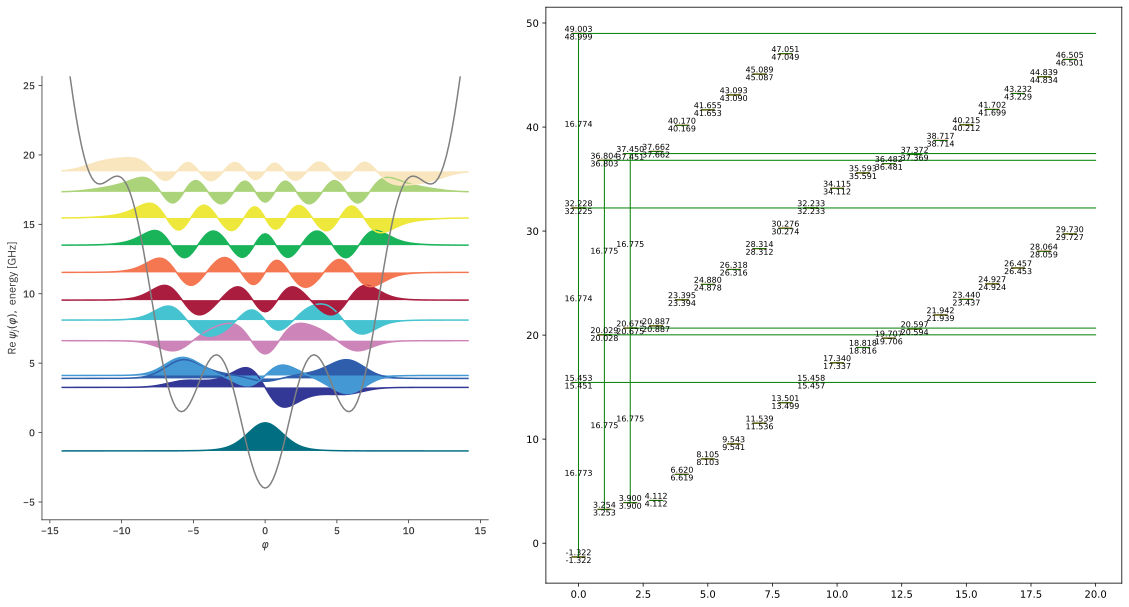

In [112]:
EJ = 4
EL = 0.3
EC = EJ/4
Er = 16.775


max_ol = 30
max_ql = 20
# g = abs(evals[7]-evals[0]-result.x[0])
# print(f"g:{g}")
g = 0.2
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,#result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

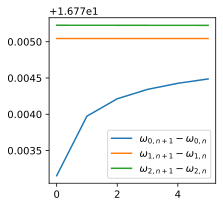

In [114]:
plt.figure(figsize = (3,3))
n_osc_lvls = 6
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::2])
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

In [1]:
import jax
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_visualization import *



n_evals = 25
def get_chi(Er,ql1,elements,evals):
    return sum([get_shift_accurate(elements[ql1,ql2], evals[ql2], evals[ql1], Er) for ql2 in range(n_evals)] )

jax_get_chi = jax.jit(jax.vmap(get_chi,in_axes = (0,None,None,None)))


def find_closest_transition(Er,evals):
    arr = np.array([evals[7]-evals[0],
                    evals[9]-evals[0],
                    evals[11]-evals[0],
                    evals[13]-evals[0]])
    names = ['07','09','011','013']
    differences = jnp.abs(arr - Er)
    closest_index = jnp.argmin(differences)
    return names[closest_index]

def get_transition(EJoverEL, EJoverEC):
    EJ = 4
    EL = EJ/EJoverEL
    EC = EJ/EJoverEC

    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL = EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
    evals = qbt.eigenvals(n_evals)
    elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    Er_list = np.linspace(evals[6]-evals[0],   evals[12]-evals[0],   int(1e6))

    chi0 = jax_get_chi(Er_list,0,elements,evals)
    chi1 = jax_get_chi(Er_list,1,elements,evals)
    chi2 = jax_get_chi(Er_list,2,elements,evals)

    one_two_crossovers = np.nonzero(np.diff(np.sign(chi1[:] - chi2[:])))[0]
    results = []
    for crossover in one_two_crossovers:
        if jnp.all(jnp.abs(chi1[crossover-10:crossover+10] - chi2[crossover-10:crossover+10]) < 1e-5):
            results.append([  Er_list[crossover]/EJ, find_closest_transition(Er_list[crossover],evals), jnp.abs(chi0[crossover] - chi1[crossover]).item()  ])
    

    return max(results, key=lambda t: t[2]) if len(results) != 0 else [None,None,None]

In [2]:

EJoverEC_list =  np.linspace(3.5,4.5,20)
EJoverEL_list = np.linspace(15,25,20)


Er_over_EJ_grid = np.zeros((len(EJoverEL_list), len(EJoverEC_list)))
closest_transition_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))
zero_one_diff_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))


for i, EJoverEL in enumerate(EJoverEL_list):
    for j, EJoverEC in tqdm(enumerate(EJoverEC_list)):
        Er_over_EJ, closest_transition,zero_one_diff = get_transition(EJoverEL, EJoverEC)
        Er_over_EJ_grid[i, j] = Er_over_EJ
        closest_transition_grid[i, j] = closest_transition
        zero_one_diff_grid[i, j] = zero_one_diff


0it [00:00, ?it/s]

20it [00:06,  2.91it/s]
20it [00:05,  3.39it/s]
20it [00:05,  3.84it/s]
20it [00:05,  3.54it/s]
20it [00:05,  3.40it/s]
20it [00:06,  2.95it/s]
20it [00:05,  3.42it/s]
20it [00:06,  3.04it/s]
20it [00:07,  2.50it/s]
20it [00:06,  3.28it/s]
20it [00:06,  2.94it/s]
20it [00:08,  2.46it/s]
20it [00:08,  2.41it/s]
20it [00:05,  3.96it/s]
20it [00:05,  3.40it/s]
20it [00:04,  4.79it/s]
20it [00:06,  2.95it/s]
20it [00:07,  2.79it/s]
20it [00:08,  2.31it/s]
20it [00:07,  2.83it/s]


Text(0.5, 1.0, 'near which transition we find $|\\chi_1=\\chi_2|$\n          and Er/EJ there')

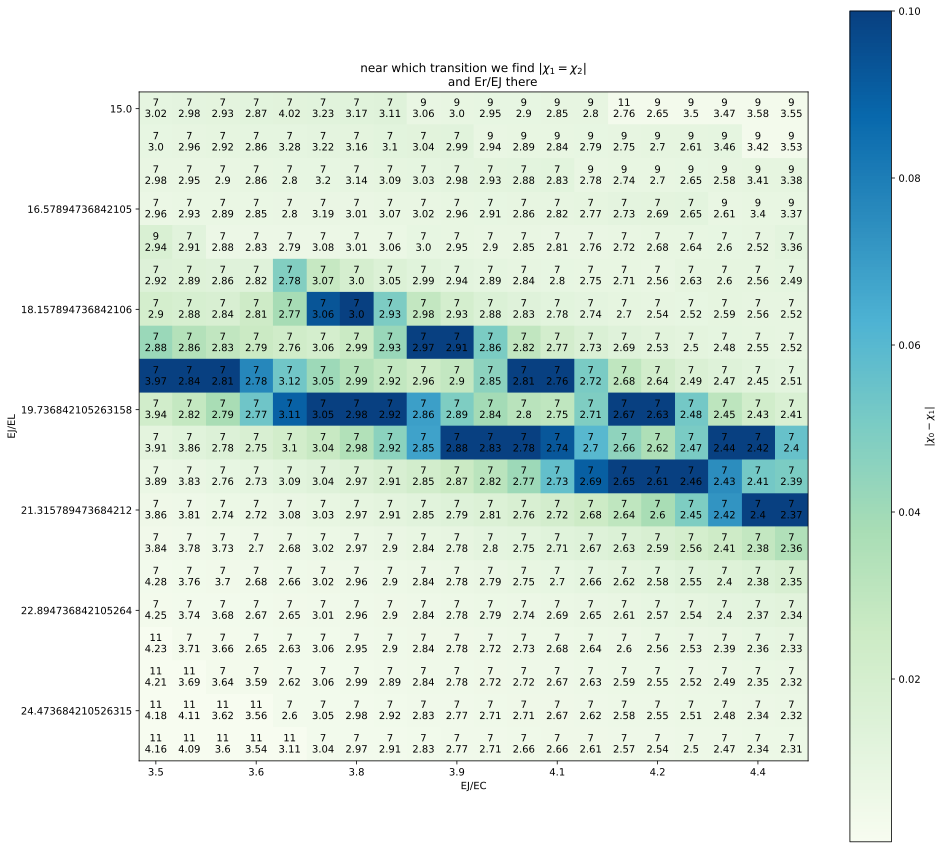

In [3]:
plt.figure(figsize=(15,15))
cmap = plt.cm.get_cmap('GnBu')
im = plt.imshow(zero_one_diff_grid, cmap=cmap,vmax = 1e-1,vmin = 5e-4)

EroverEJ_trunc = np.trunc(Er_over_EJ_grid* 100) / 100
for (j,i),label in np.ndenumerate(closest_transition_grid):
    plt.text(i,j,str(int(label))+'\n'+str(EroverEJ_trunc[i,j]),ha='center',va='center')

plt.xticks(ticks = range(len(EJoverEC_list))[::3],labels = np.trunc(EJoverEC_list[::3] * 10) / 10)
plt.yticks(ticks = range(len(EJoverEL_list))[::3],labels = EJoverEL_list[::3])
cbar = plt.colorbar(im)
cbar.set_label(r'$|\chi_0-\chi_1|$')
plt.xlabel(rf'EJ/EC')
plt.ylabel(rf'EJ/EL')
plt.title(r'''near which transition we find $|\chi_1=\chi_2|$
          and Er/EJ there''')

# Next we use diagonalization to find the exact value of  $|\chi_0-\chi_1|$

In [7]:
zero_one_diff_diagonalization_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))

for i, EJoverEL in tqdm(enumerate(EJoverEL_list)):
    for j, EJoverEC in enumerate(EJoverEC_list):
        EJ = 4
        EL = EJ/EJoverEL
        EC = EJ/EJoverEC
        Er = EJ * Er_over_EJ_grid[i,j]
        
        max_ol = 30
        max_ql = 20
        g = 0.13
        system = FluxoniumOscillatorSystem(
            EJ = EJ,
            EC = EC,
            EL = EL,
            Er = Er,
            g_strength = g,
            qubit_level = max_ql,
            osc_level = max_ol,
            computaional_states = '1,2'
            )


        energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
        def dressed_ener(ql,ol):
            return energies[system.product_to_dressed[(ql,ol)]]
        zero_one_diff_diagonalization_grid[i,j] = abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))

20it [18:11, 54.56s/it]


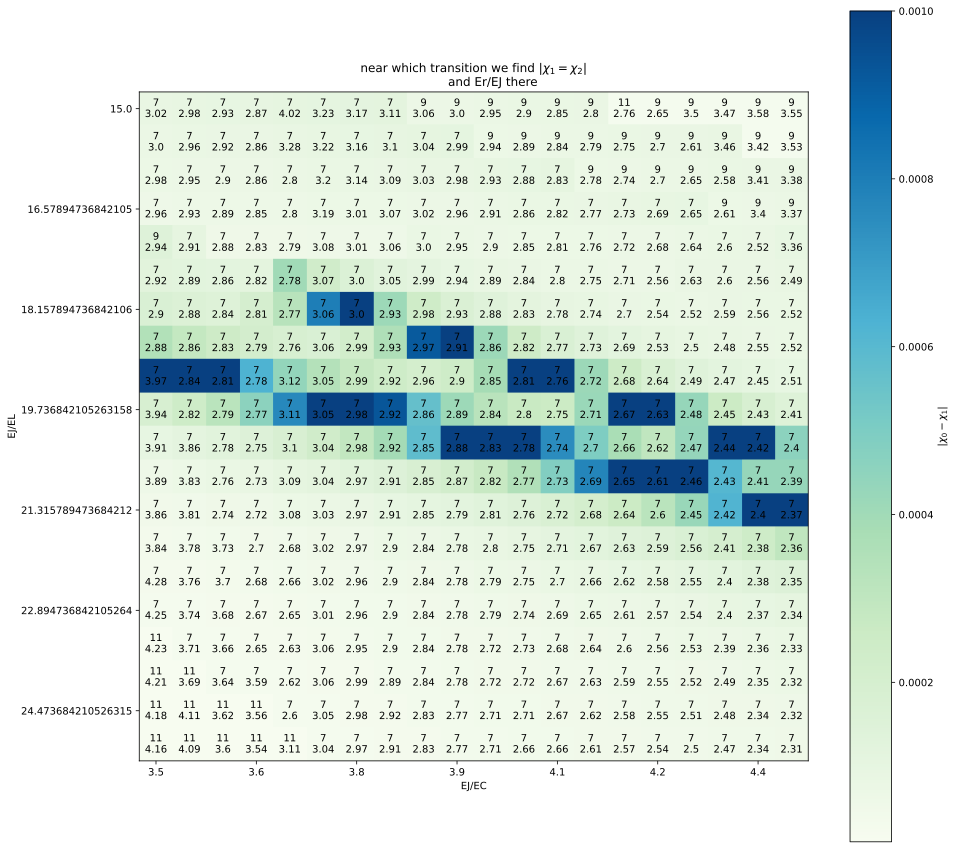

In [14]:
plt.figure(figsize=(15,15))

cmap = plt.cm.get_cmap('GnBu')
im = plt.imshow(zero_one_diff_diagonalization_grid, cmap=cmap,vmax = 1e-3,vmin = 1e-5)

EroverEJ = np.trunc(Er_over_EJ_grid* 100) / 100
for (j,i),label in np.ndenumerate(closest_transition_grid):
    plt.text(i,j,str(int(label))+'\n'+str(EroverEJ[i,j]),ha='center',va='center')

plt.xticks(ticks = range(len(EJoverEC_list))[::3],labels = np.trunc(EJoverEC_list[::3] * 10) / 10)
plt.yticks(ticks = range(len(EJoverEL_list))[::3],labels = EJoverEL_list[::3])
cbar = plt.colorbar(im)
cbar.set_label(r'$|\chi_0-\chi_1|$')
plt.xlabel(rf'EJ/EC')
plt.ylabel(rf'EJ/EL')
plt.title(r'''near which transition we find $|\chi_1=\chi_2|$
          and Er/EJ there''')

plt.savefig('fig01_where_to_find_good_params.pdf', format='pdf', bbox_inches='tight')
